# Project - 2 : Salary Prediction
**Dataset:** Pakistan Salary Dataset  
**Target:** `salary_monthly`  
**Approach:** Single Feature vs Multiple Feature Linear Regression

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import root_mean_squared_error, r2_score

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor'  : BG,
    'axes.edgecolor'  : '#BCCAD6',
    'axes.labelcolor' : '#1A1A2E',
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor' : '#1A1A2E',
    'xtick.color'     : '#3A3A5C',
    'ytick.color'     : '#3A3A5C',
    'font.family'     : 'DejaVu Sans',
    'grid.color'      : C_GRID,
    'grid.linewidth'  : 0.7,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [28]:
df = pd.read_csv('salary_dataset_pakistan.csv')

# Drop columns not useful for modelling
df.drop(columns=['name', 'salary_yearly'], inplace=True)

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')
df.head()

Shape  : (100, 5)
Columns: ['age', 'education_level', 'skill_score', 'city', 'salary_monthly']

Null values:
age                0
education_level    0
skill_score        0
city               0
salary_monthly     0
dtype: int64

Data types:
age                 int64
education_level    object
skill_score         int64
city               object
salary_monthly      int64
dtype: object


,age,education_level,skill_score,city,salary_monthly
0,24,High School,5,Lahore,66057
1,44,High School,9,Karachi,130074
2,22,High School,4,Lahore,61079
3,21,Bachelor,9,Rawalpindi,115611
4,39,Intermediate,1,Lahore,60838


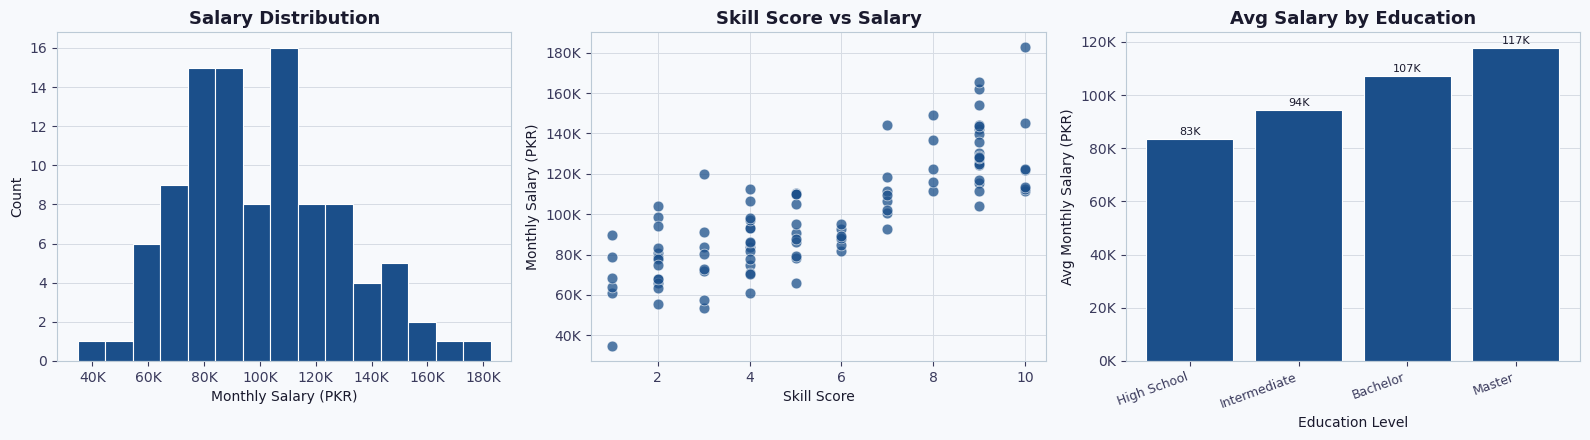

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor(BG)

# ── Plot 1 : Salary distribution ──
ax = axes[0]
ax.hist(df['salary_monthly'], bins=15, color=C_BAR, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Monthly Salary (PKR)')
ax.set_ylabel('Count')
ax.set_title('Salary Distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.grid(axis='y')
ax.set_axisbelow(True)

# ── Plot 2 : Skill Score vs Salary ──
ax = axes[1]
ax.scatter(df['skill_score'], df['salary_monthly'], color=C_BAR,
           alpha=0.75, edgecolors='white', linewidth=0.5, s=60)
ax.set_xlabel('Skill Score')
ax.set_ylabel('Monthly Salary (PKR)')
ax.set_title('Skill Score vs Salary')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.grid(True)
ax.set_axisbelow(True)

# ── Plot 3 : Avg Salary by Education ──
edu_order = ['High School', 'Intermediate', 'Bachelor', 'Master']
avg_sal   = df.groupby('education_level')['salary_monthly'].mean().reindex(edu_order)
ax = axes[2]
bars = ax.bar(avg_sal.index, avg_sal.values, color=C_BAR, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Education Level')
ax.set_ylabel('Avg Monthly Salary (PKR)')
ax.set_title('Avg Salary by Education')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.set_xticklabels(edu_order, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y')
ax.set_axisbelow(True)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
            f'{int(bar.get_height()/1000)}K', ha='center', va='bottom', fontsize=8, color='#1A1A2E')

plt.tight_layout()
plt.show()

In [30]:
# Ordinal encode education (ordered: High School < Intermediate < Bachelor < Master)
edu_categories = [['High School', 'Intermediate', 'Bachelor', 'Master']]
oe = OrdinalEncoder(categories=edu_categories)
df['education_encoded'] = oe.fit_transform(df[['education_level']]).astype(int)

# One-hot encode city
df = pd.get_dummies(df, columns=['city'], prefix='city', drop_first=True, dtype=int)

print('Encoding complete.')
print(f'Shape after encoding: {df.shape}')
df.head(3)

Encoding complete.
Shape after encoding: (100, 10)


,age,education_level,skill_score,salary_monthly,education_encoded,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Rawalpindi
0,24,High School,5,66057,0,0,0,1,0,0
1,44,High School,9,130074,0,0,1,0,0,0
2,22,High School,4,61079,0,0,0,1,0,0


In [31]:
TARGET  = 'salary_monthly'
DROP_COLS = ['education_level', TARGET]

# All numeric features (after encoding)
X_all = df.drop(columns=DROP_COLS)
y     = df[TARGET]

# Single feature: skill_score (highest correlation = 0.80)
X_single = df[['skill_score']]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_single, y, test_size=0.20, random_state=42)

X_train_m, X_test_m, _, _ = train_test_split(
    X_all, y, test_size=0.20, random_state=42)

print(f'Train size : {len(y_train)}')
print(f'Test  size : {len(y_test)}')
print(f'Single-feature columns : {X_single.columns.tolist()}')
print(f'Multi-feature  columns : {X_all.columns.tolist()}')

Train size : 80
Test  size : 20
Single-feature columns : ['skill_score']
Multi-feature  columns : ['age', 'skill_score', 'education_encoded', 'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Multan', 'city_Rawalpindi']


In [32]:
scaler_s = StandardScaler()
scaler_m = StandardScaler()

X_train_s_sc = scaler_s.fit_transform(X_train_s)
X_test_s_sc  = scaler_s.transform(X_test_s)

X_train_m_sc = scaler_m.fit_transform(X_train_m)
X_test_m_sc  = scaler_m.transform(X_test_m)

print('Scaling complete — StandardScaler applied to both feature sets.')

Scaling complete — StandardScaler applied to both feature sets.


In [33]:
#Single Feature Model 
model_single = LinearRegression()
model_single.fit(X_train_s_sc, y_train)

#Multiple Feature Model 
model_multi = LinearRegression()
model_multi.fit(X_train_m_sc, y_train)

print('Both models trained successfully.')

Both models trained successfully.


In [34]:
def evaluate_model(model, X_test_sc, y_test, label):
    y_pred = model.predict(X_test_sc)
    rmse   = root_mean_squared_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    print(f'  {label}')
    print(f'    RMSE : {rmse:,.0f} PKR')
    print(f'    R²   : {r2:.4f}  ({r2*100:.2f}% variance explained)')
    print()
    return y_pred, rmse, r2

print('  MODEL EVALUATION RESULTS')
y_pred_s, rmse_s, r2_s = evaluate_model(model_single, X_test_s_sc, y_test, 'Single Feature  (skill_score)')
y_pred_m, rmse_m, r2_m = evaluate_model(model_multi,  X_test_m_sc, y_test, 'Multiple Features (all)')


  MODEL EVALUATION RESULTS
  Single Feature  (skill_score)
    RMSE : 19,820 PKR
    R²   : 0.5703  (57.03% variance explained)

  Multiple Features (all)
    RMSE : 4,501 PKR
    R²   : 0.9778  (97.78% variance explained)



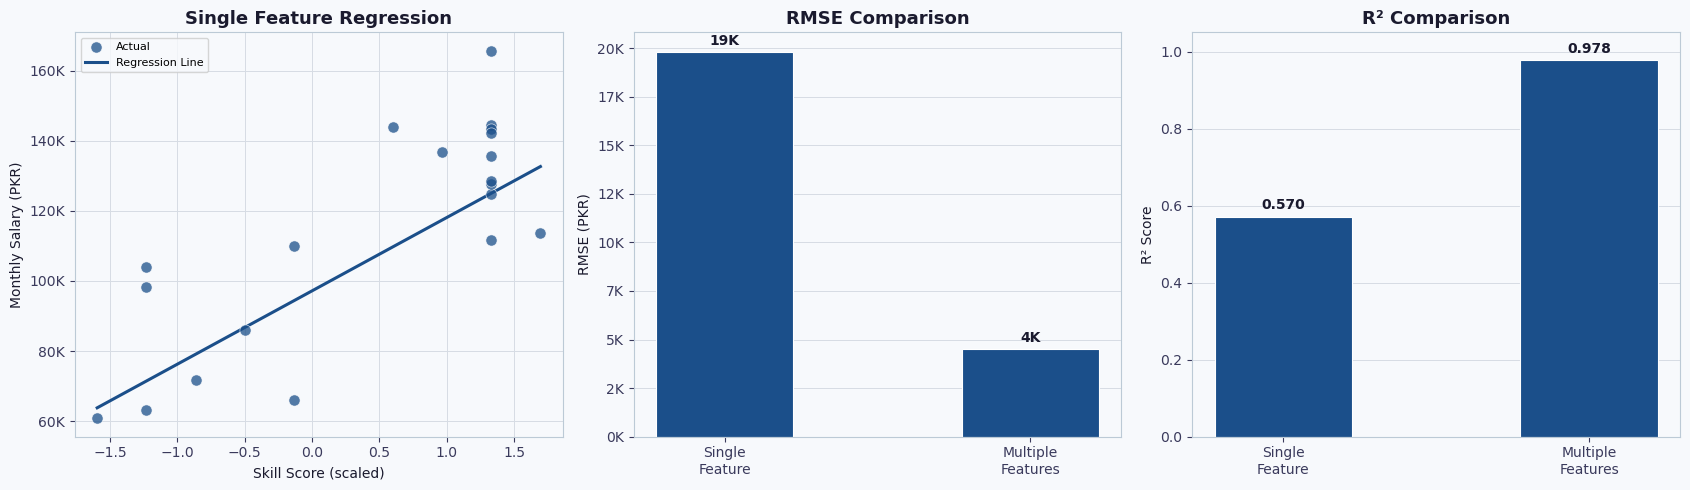

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(BG)

# ── Plot 1 : Single Feature Regression Line ──
ax = axes[0]
x_range  = np.linspace(X_test_s_sc.min(), X_test_s_sc.max(), 200).reshape(-1, 1)
y_line_s = model_single.predict(x_range)
ax.scatter(X_test_s_sc, y_test, color=C_BAR, alpha=0.75, edgecolors='white',
           linewidth=0.5, s=65, zorder=3, label='Actual')
ax.plot(x_range, y_line_s, color=C_LINE, linewidth=2.2, label='Regression Line')
ax.set_xlabel('Skill Score (scaled)')
ax.set_ylabel('Monthly Salary (PKR)')
ax.set_title('Single Feature Regression')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.legend(fontsize=8)
ax.grid(True)
ax.set_axisbelow(True)

# ── Plot 2 : RMSE Comparison Bar ──
ax = axes[1]
labels = ['Single\nFeature', 'Multiple\nFeatures']
rmse_vals = [rmse_s, rmse_m]
bars = ax.bar(labels, rmse_vals, color=C_BAR, width=0.45, edgecolor='white', linewidth=0.8)
ax.set_ylabel('RMSE (PKR)')
ax.set_title('RMSE Comparison')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.grid(axis='y')
ax.set_axisbelow(True)
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(val/1000)}K', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1A1A2E')

# ── Plot 3 : R² Comparison Bar ──
ax = axes[2]
r2_vals = [r2_s, r2_m]
bars = ax.bar(labels, r2_vals, color=C_BAR, width=0.45, edgecolor='white', linewidth=0.8)
ax.set_ylabel('R² Score')
ax.set_title('R² Comparison')
ax.set_ylim(0, 1.05)
ax.grid(axis='y')
ax.set_axisbelow(True)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1A1A2E')

plt.tight_layout()
plt.show()

Best Model → Multiple Feature Model


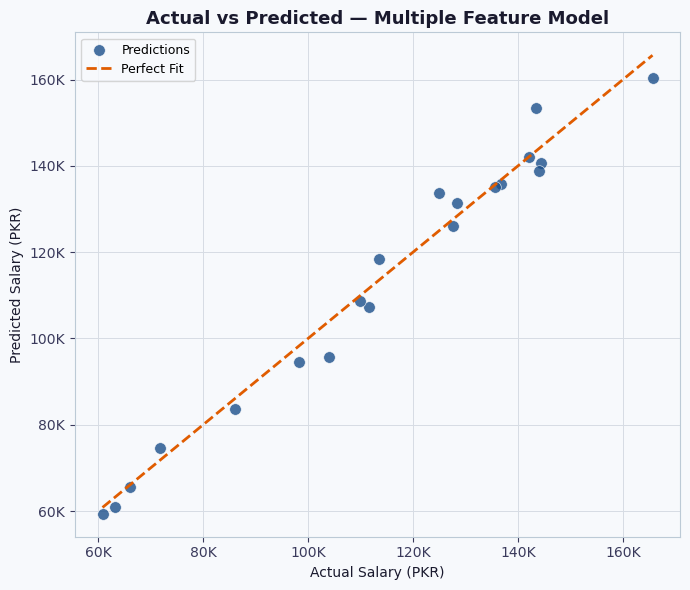

In [36]:
# Decide best model based on R²
if r2_m >= r2_s:
    best_model   = model_multi
    best_scaler  = scaler_m
    y_pred_best  = y_pred_m
    best_label   = 'Multiple Feature Model'
else:
    best_model   = model_single
    best_scaler  = scaler_s
    y_pred_best  = y_pred_s
    best_label   = 'Single Feature Model'

print(f'Best Model → {best_label}')

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)

ax.scatter(y_test, y_pred_best, color=C_BAR, alpha=0.80,
           edgecolors='white', linewidth=0.5, s=70, label='Predictions')

# Perfect prediction line
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], color=C_PRED, linewidth=2, linestyle='--', label='Perfect Fit')

ax.set_xlabel('Actual Salary (PKR)')
ax.set_ylabel('Predicted Salary (PKR)')
ax.set_title(f'Actual vs Predicted — {best_label}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.legend(fontsize=9)
ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

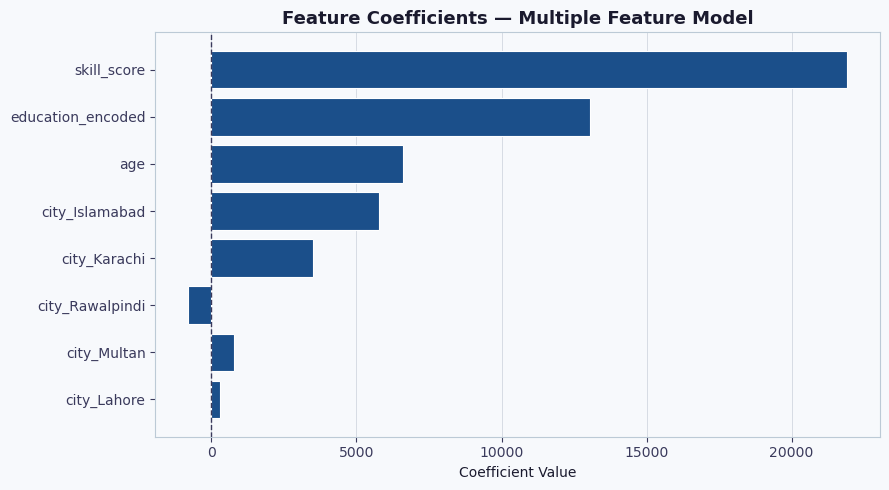

          Feature  Coefficient
      skill_score 21914.971814
education_encoded 13046.308962
              age  6599.751787
   city_Islamabad  5762.812883
     city_Karachi  3516.507020
  city_Rawalpindi  -800.157960
      city_Multan   784.749605
      city_Lahore   284.964617


In [37]:


coeff_df = pd.DataFrame({
    'Feature'    : X_all.columns,
    'Coefficient': model_multi.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

ax.barh(coeff_df['Feature'], coeff_df['Coefficient'],
        color=C_BAR, edgecolor='white', linewidth=0.8)
ax.axvline(0, color='#3A3A5C', linewidth=1, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Feature Coefficients — Multiple Feature Model')
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(coeff_df.sort_values('Coefficient', key=abs, ascending=False).to_string(index=False))

In [38]:
os.makedirs('saved_model', exist_ok=True)

joblib.dump(best_model,  'saved_model/salary_model.pkl')
joblib.dump(best_scaler, 'saved_model/salary_scaler.pkl')

print(f'Saved → saved_model/salary_model.pkl   ({best_label})')
print(f'Saved → saved_model/salary_scaler.pkl')

Saved → saved_model/salary_model.pkl   (Multiple Feature Model)
Saved → saved_model/salary_scaler.pkl
